# Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                           mean_absolute_error, precision_recall_curve, roc_curve, auc)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb
from sklearn.feature_selection import SelectFromModel

import shap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load and Visualize SCADA Dataset

In [2]:
# Load data
data = pd.read_csv('wedowind.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)

In [3]:
data = data[(data['power'] > 0) & (data['rotor_speed'] > 0)]


In [4]:
# Check missing values
print(data.isnull().sum())

plant_name               0
timestamp                0
wind_speed               0
turbulence_intensity     0
nacelle_direction        0
rotor_speed              0
generator_speed          0
blade_angle_1            0
blade_angle_2            0
blade_angle_3            0
power                    0
cosphi                   0
temp_environment         0
generator_temperature    0
break_temperature        0
temp_hydraulic_oil       0
bearing_temperature      0
hydraulic_pressure       0
gear_pressure            0
wind_direction           0
wind_speed_reference     0
airpressure              0
humidity                 0
errorcode                0
dtype: int64


In [5]:
data['timestamp'] = pd.to_datetime(data['timestamp'])

In [6]:
print("Fault class distribution:\n", data["errorcode"].value_counts())  # Assuming 'errorcode' is the target


Fault class distribution:
 errorcode
0    432808
1     37645
Name: count, dtype: int64


# Pre-processing

In [7]:
data['hour'] = data['timestamp'].dt.hour
data['day_of_week'] = data['timestamp'].dt.dayofweek
data['day_of_year'] = data['timestamp'].dt.dayofyear

In [8]:
# Prepare features for clustering
features = data.drop(['timestamp', 'plant_name', 'errorcode'], axis=1)

# Handle missing values - two options:

# Option 1: Drop rows with any missing values (if few missing values)
data_cleaned = data.dropna().copy()
features_cleaned = features.dropna().copy()

# Verify no missing values remain
print(f"Remaining missing values: {features_cleaned.isna().sum().sum()}")

Remaining missing values: 0


In [9]:
# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_cleaned)

# Unsupervised Learning for Feature Selection

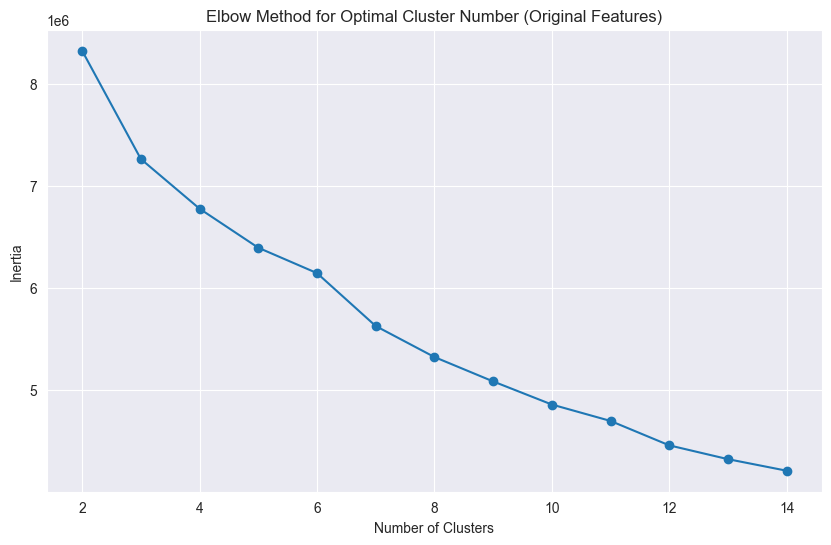

In [10]:
# Determine optimal number of clusters on original scaled features
inertia = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 15), inertia, marker='o')
plt.title('Elbow Method for Optimal Cluster Number (Original Features)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [11]:
# Fit with optimal clusters (using 5 as in your original code)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
data_cleaned['cluster'] = clusters

In [12]:
# Now perform PCA for visualization and analysis
pca = PCA(n_components=0.95)
principal_components = pca.fit_transform(scaled_features)
print(f"Reduced to {principal_components.shape[1]} principal components")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")

Reduced to 12 principal components
Explained variance ratio: 0.96


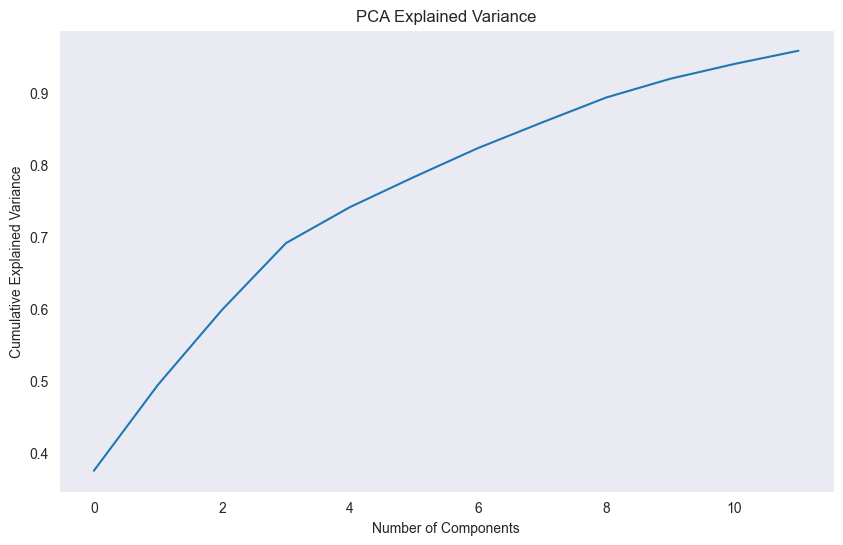

In [13]:
# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()


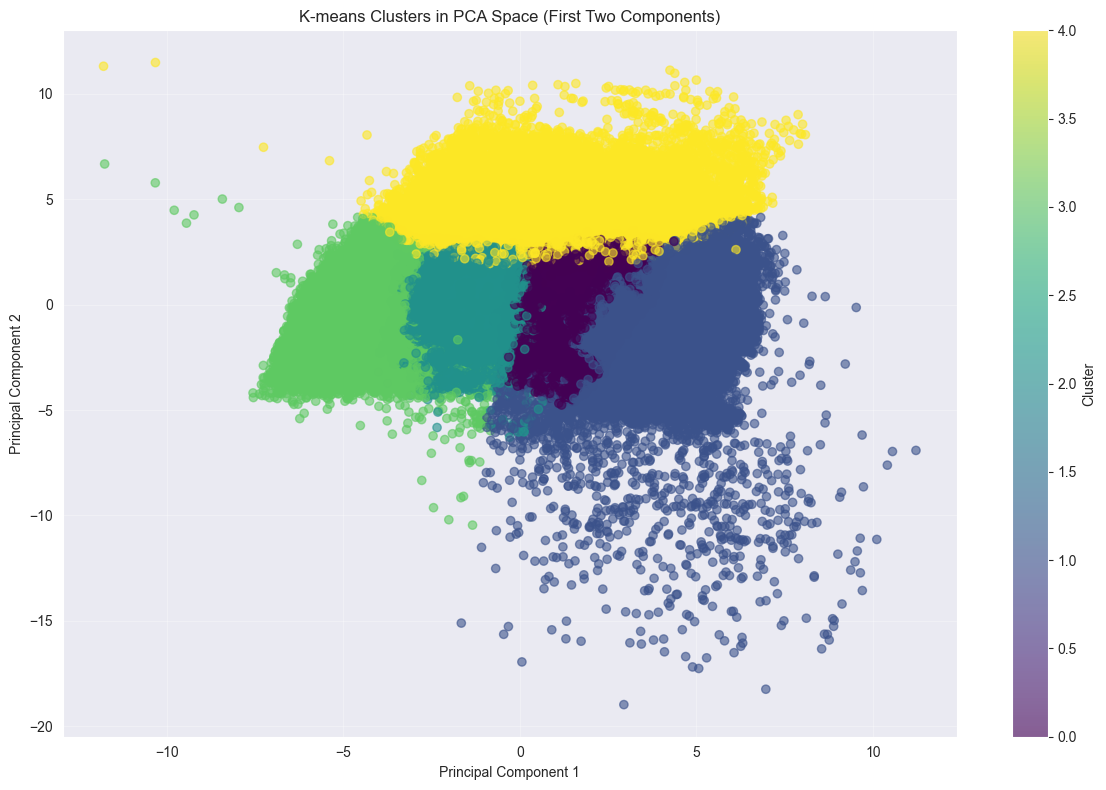


Cluster Analysis Complete
Cluster distribution:
cluster
2    139606
0    122655
1     94331
3     87186
4     26675
Name: count, dtype: int64


In [14]:
# Visualize clusters in PCA space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(principal_components[:, 0],
                     principal_components[:, 1],
                     c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('K-means Clusters in PCA Space (First Two Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCluster Analysis Complete")
print(f"Cluster distribution:\n{data_cleaned['cluster'].value_counts()}")

# Supervised Learning

In [15]:
# First create binary failure indicator
data_cleaned['failure'] = (data_cleaned['errorcode'] != 0).astype(int)

# Your exact TTF calculation function
def create_ttf_feature(group):
    """Create Time-to-Failure feature following paper's exact methodology"""
    group = group.sort_values('timestamp')
    group['ttf'] = 0.0

    failure_indices = group.index[group['failure'] == 1].tolist()

    # Calculate time until next failure for each point
    for i in range(len(group)):
        current_time = group.iloc[i]['timestamp']
        future_failures = group[(group['timestamp'] > current_time) & (group['failure'] == 1)]

        if not future_failures.empty:
            next_failure_time = future_failures.iloc[0]['timestamp']
            ttf_hours = (next_failure_time - current_time).total_seconds() / 3600
            group.loc[group.index[i], 'ttf'] = ttf_hours
        else:
            # No future failures in this turbine's data
            group.loc[group.index[i], 'ttf'] = np.nan

    return group


In [16]:
# Apply TTF creation to each turbine separately
data_ttf = data_cleaned.groupby('plant_name', group_keys=False).apply(create_ttf_feature)

# Clean and filter data as specified in paper
data_ttf = data_ttf.dropna(subset=['ttf'])  # Remove unknown TTF
data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]  # Last 15h before failure
data_ttf = data_ttf[data_ttf['failure'] == 0]  # Remove actual failure points

In [17]:
print(f"\nTTF Dataset Prepared: {len(data_ttf)} records")
print(f"Time-to-Failure range: {data_ttf['ttf'].min():.1f} to {data_ttf['ttf'].max():.1f} hours")


TTF Dataset Prepared: 61210 records
Time-to-Failure range: 0.2 to 15.0 hours


In [25]:
selected_features = [col for col in data_ttf.columns
                    if col not in ['timestamp', 'plant_name', 'errorcode', 'failure', 'ttf', 'cluster']
                    and data_ttf[col].dtype in ['int64', 'float64']]

# Now you can filter to only include columns that exist in data_ttf
selected_features = [f for f in selected_features if f in data_ttf.columns]
# Prepare features and target using selected features from clustering
X = data_ttf[selected_features]
y = data_ttf['ttf']
groups = data_ttf['plant_name']

# Leave-One-Turbine-Out cross validation
logo = LeaveOneGroupOut()
mae_results = {}
predictions = {}

In [26]:
# Initialize dictionaries to store results for both models
xgb_mae_results = {}
rf_mae_results = {}
predictions = {}  # Will store both models' predictions

for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    turbine_id = groups.iloc[test_index[0]]

    # --- XGBoost Model ---
    xgb_model = xgb.XGBRegressor(
        n_estimators=300, max_depth=7, learning_rate=0.2,
                   subsample=0.8, colsample_bytree=1.0, random_state=42
    )
    xgb_model.fit(X_train, y_train)
    y_pred_xgb = xgb_model.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
    xgb_mae_results[turbine_id] = xgb_mae

    # --- Random Forest Model ---
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    rf_mae_results[turbine_id] = rf_mae

    # Store predictions for analysis
    predictions[turbine_id] = {
        'actual': y_test.values,
        'xgb_predicted': y_pred_xgb,
        'rf_predicted': y_pred_rf,
        'timestamps': data_ttf.iloc[test_index]['timestamp'].values,
        'features': X_test.values
    }


In [27]:
print("\nModel Comparison - MAE Results by Turbine (hours):")
print("Turbine ID | XGBoost MAE | RF MAE | Records")
print("--------------------------------------------")
for turbine_id in sorted(predictions.keys()):
    rec_count = len(predictions[turbine_id]['actual'])
    print(f"{turbine_id:9} | {xgb_mae_results[turbine_id]:.2f} | {rf_mae_results[turbine_id]:.2f} | {rec_count:7}")


Model Comparison - MAE Results by Turbine (hours):
Turbine ID | XGBoost MAE | RF MAE | Records
--------------------------------------------
      109 | 3.29 | 3.19 |    9854
      114 | 2.92 | 2.84 |    9403
      115 | 3.34 | 3.17 |   16089
      116 | 3.47 | 3.32 |   15681
      120 | 3.07 | 3.00 |   10183


In [28]:
def plot_ttf_comparison(turbine_id, predictions):
    if turbine_id not in predictions:
        print(f"No data for turbine {turbine_id}")
        return

    data = predictions[turbine_id]
    obs_numbers = np.arange(len(data['timestamps']))

    plt.figure(figsize=(14, 6))
    plt.plot(obs_numbers, data['actual'], label='Actual TTF', color='blue', linewidth=1.5)
    plt.plot(obs_numbers, data['xgb_predicted'], label='XGBoost Predicted', color='orange', linestyle='--', linewidth=1.5)
    plt.plot(obs_numbers, data['rf_predicted'], label='RF Predicted', color='green', linestyle=':', linewidth=1.5)



    plt.title(f"Model Comparison for Turbine #{turbine_id}\nXGB MAE: {xgb_mae_results[turbine_id]:.2f}h, RF MAE: {rf_mae_results[turbine_id]:.2f}h", pad=20)
    plt.xlabel("Observation Number")
    plt.ylabel("Time to Failure (hours)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    if len(obs_numbers) > 5700:
        plt.xlim(4500, 6000)

    plt.tight_layout()
    plt.show()

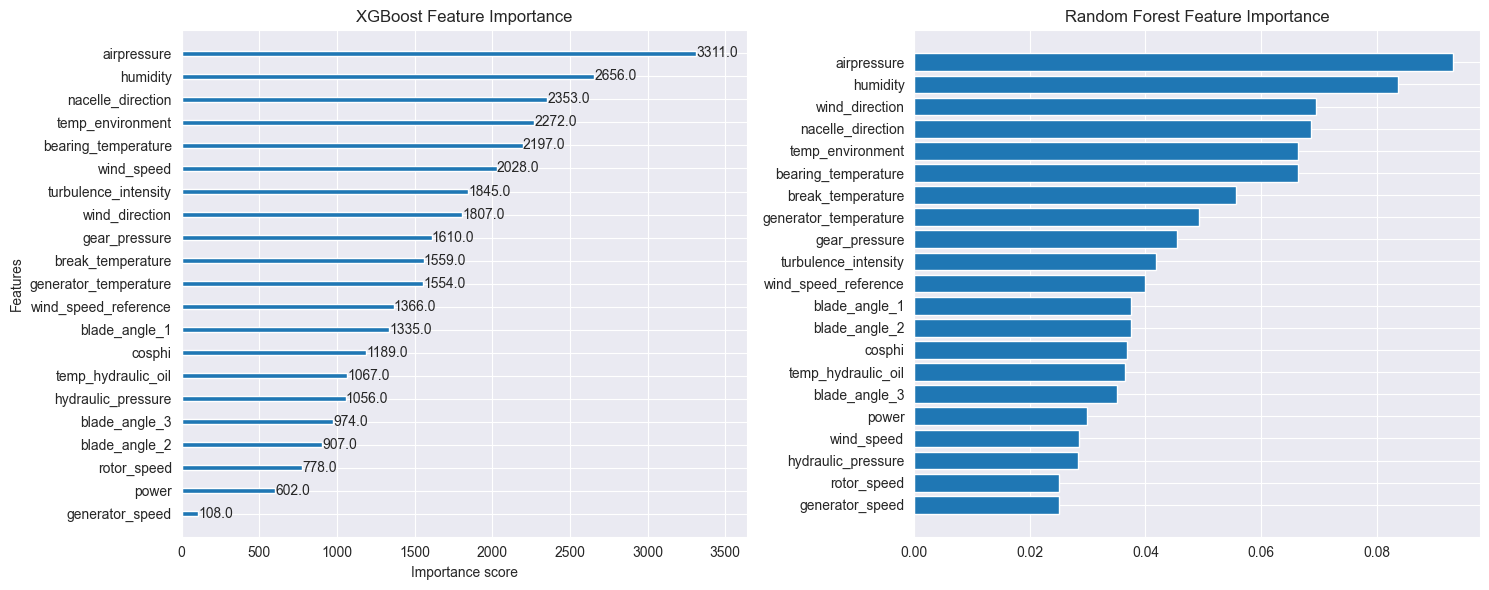

In [29]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
xgb.plot_importance(xgb_model, ax=plt.gca())
plt.title('XGBoost Feature Importance')

plt.subplot(1, 2, 2)
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)
plt.barh(range(len(sorted_idx)), importances[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(selected_features)[sorted_idx])
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()


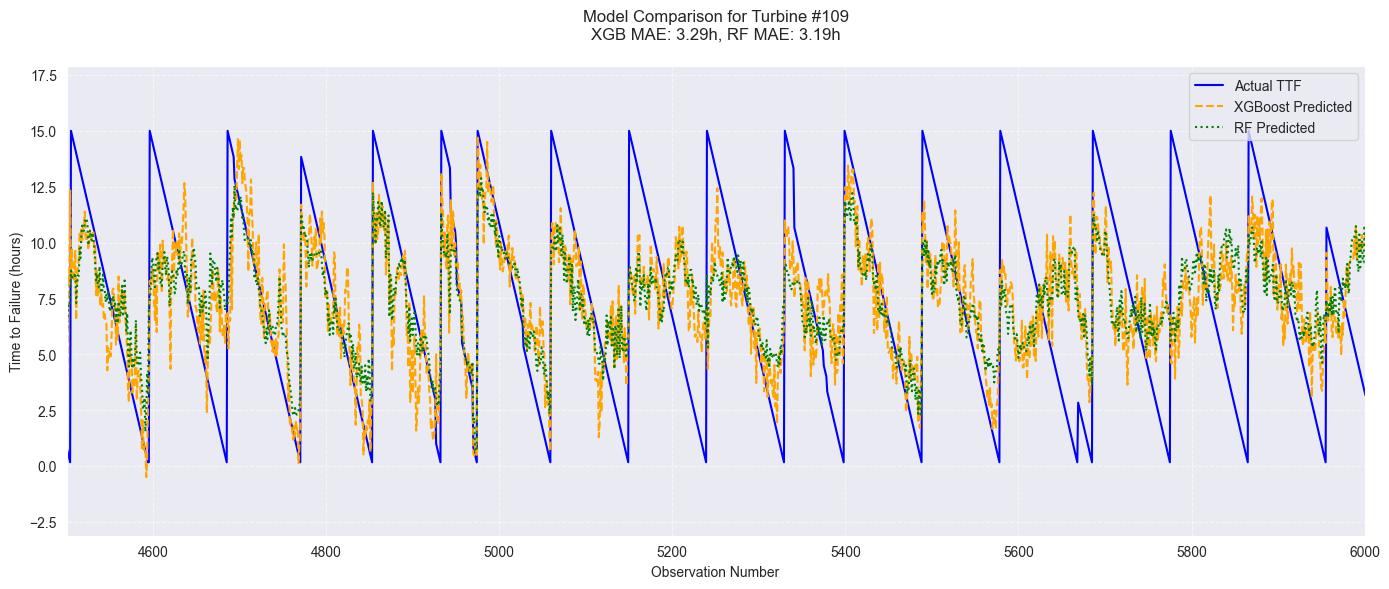

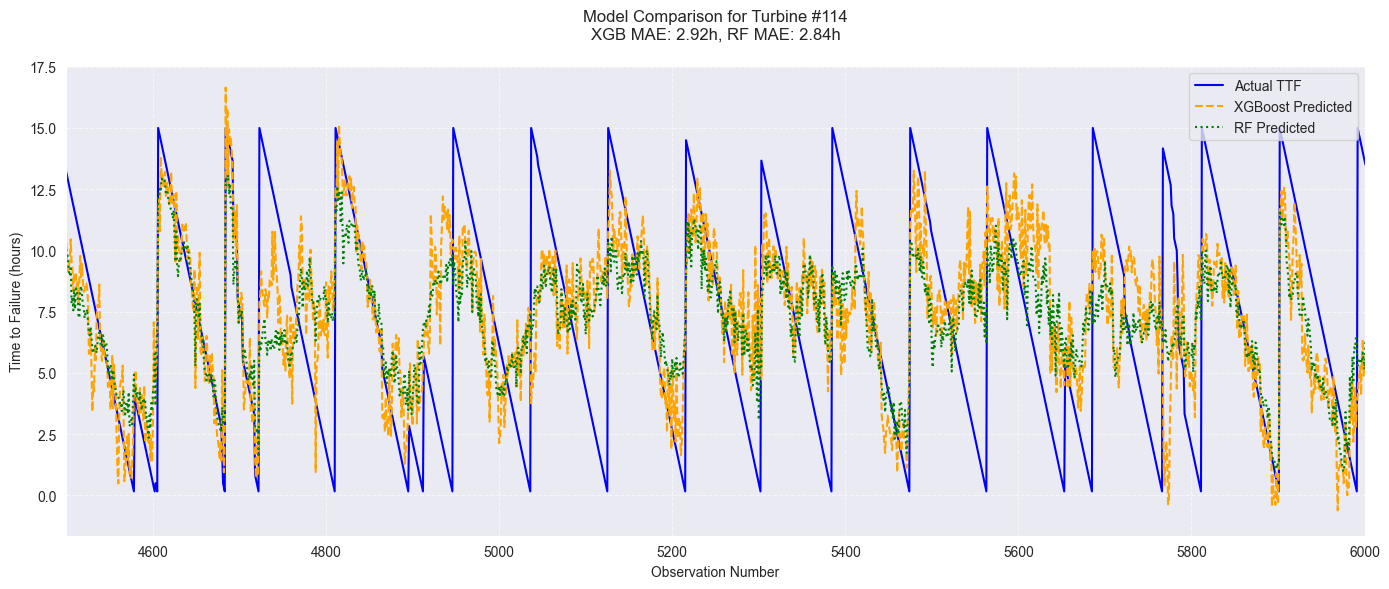

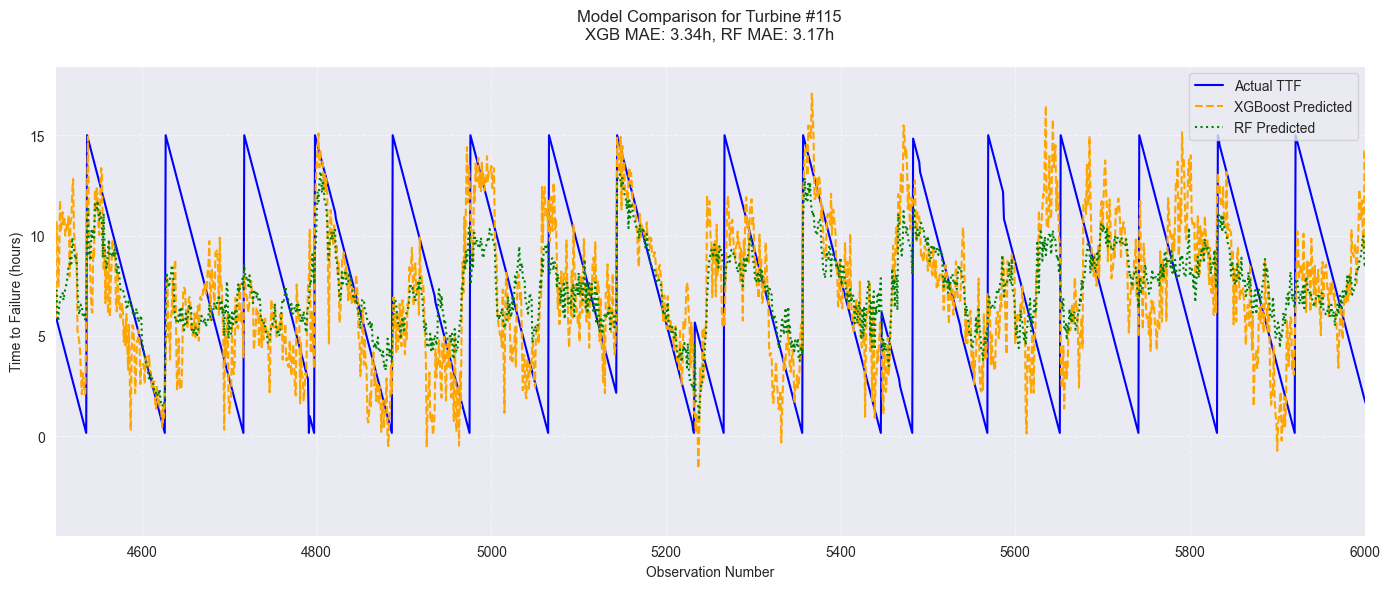

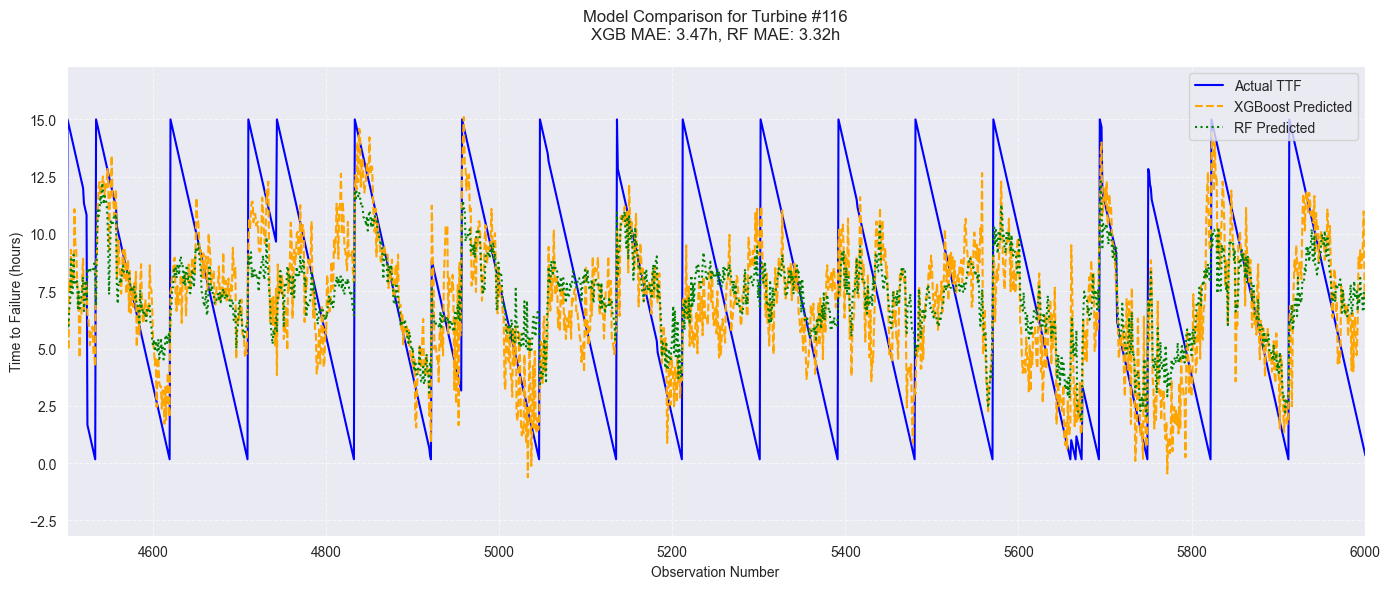

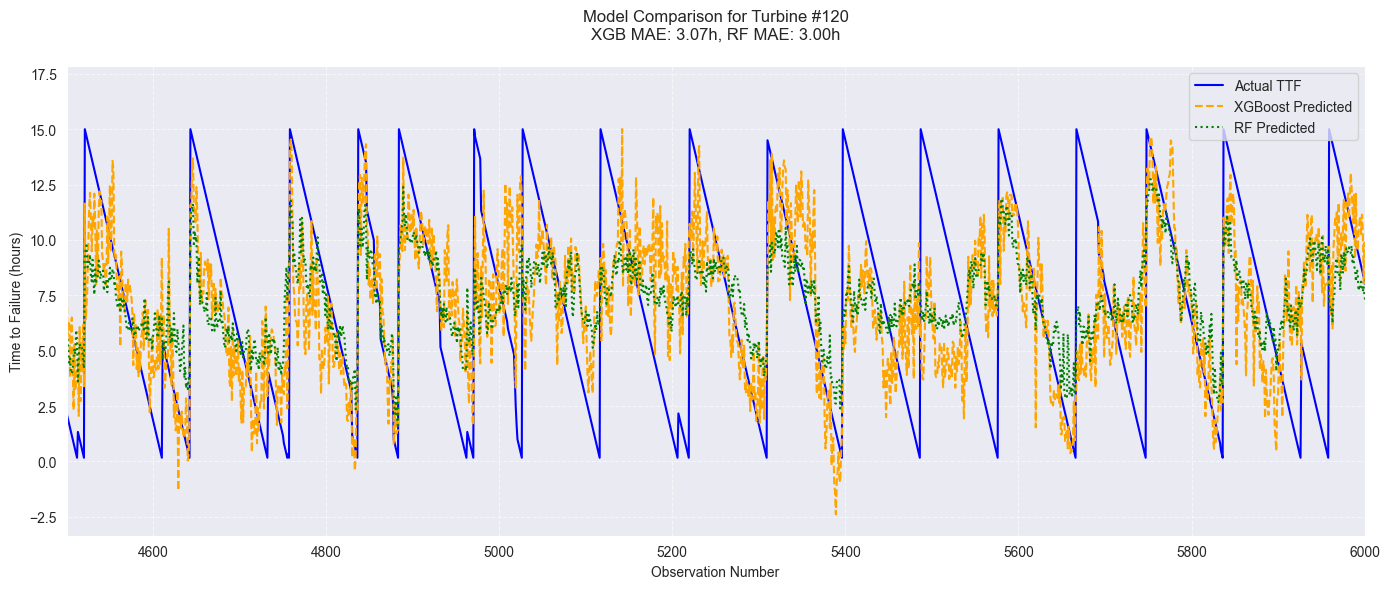


Generating SHAP explanations...


<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

In [30]:
for turbine_id in predictions.keys():
    plot_ttf_comparison(turbine_id, predictions)

# SHAP analysis for both models
print("\nGenerating SHAP explanations...")
plt.figure(figsize=(15, 6))



Optimizing models for turbine 109...
Running Bayesian Optimization for XGBoost...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 ca

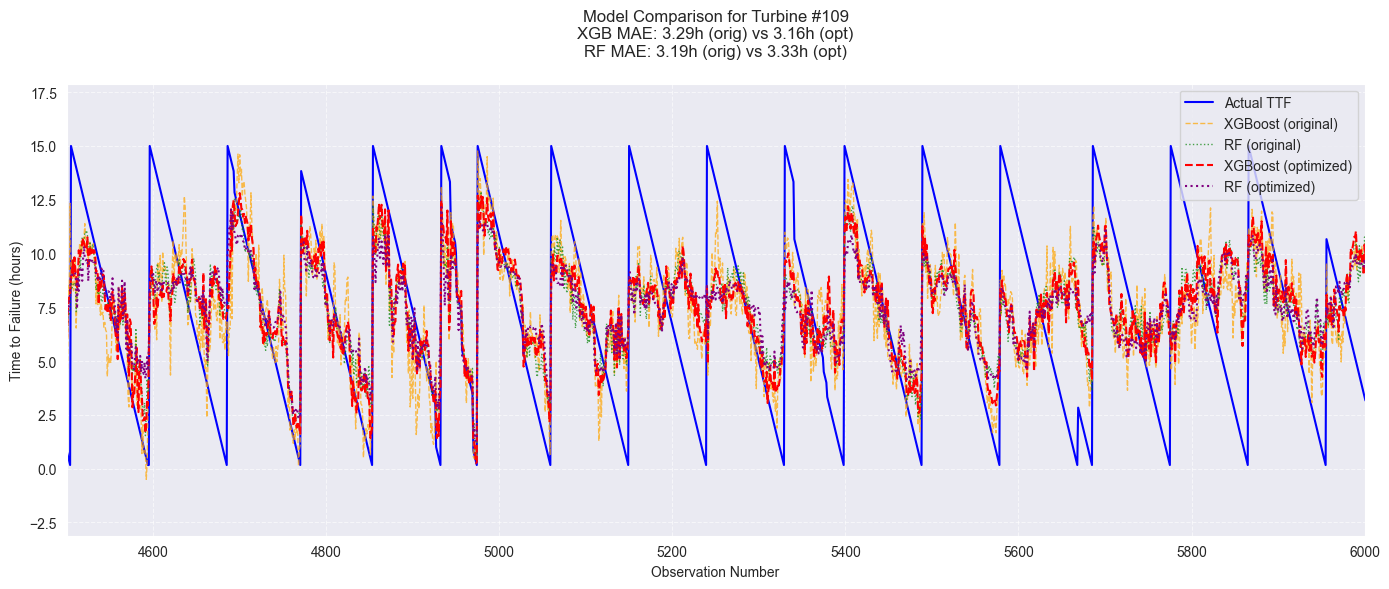

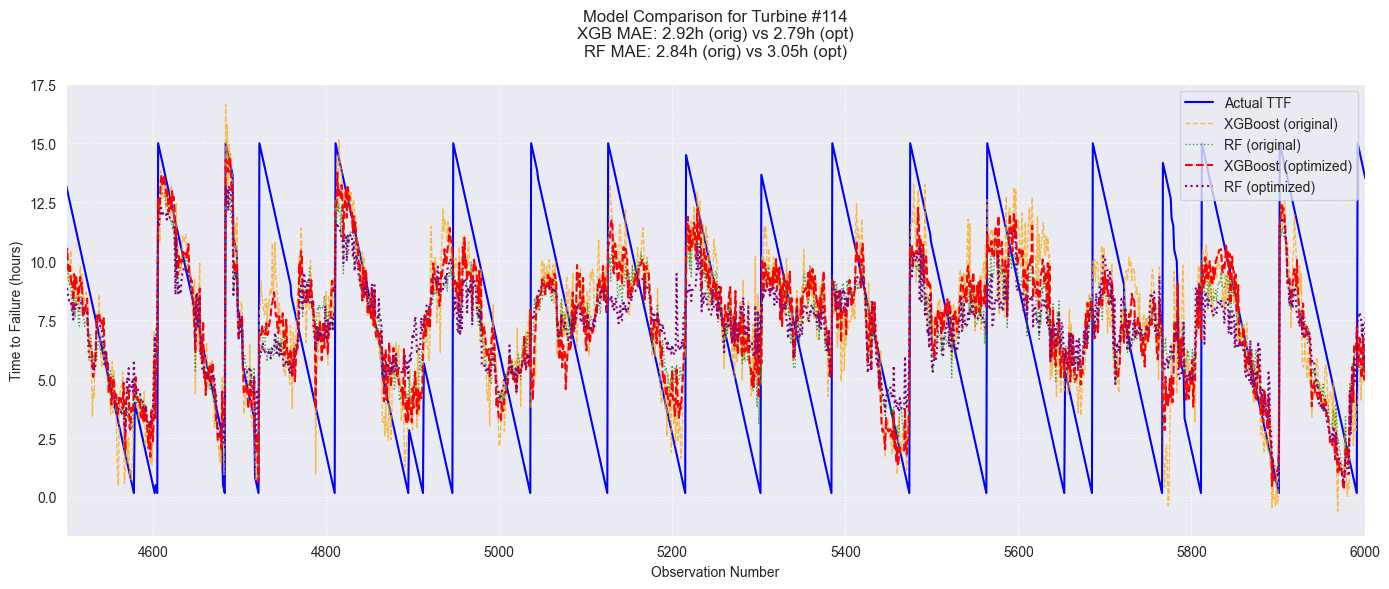

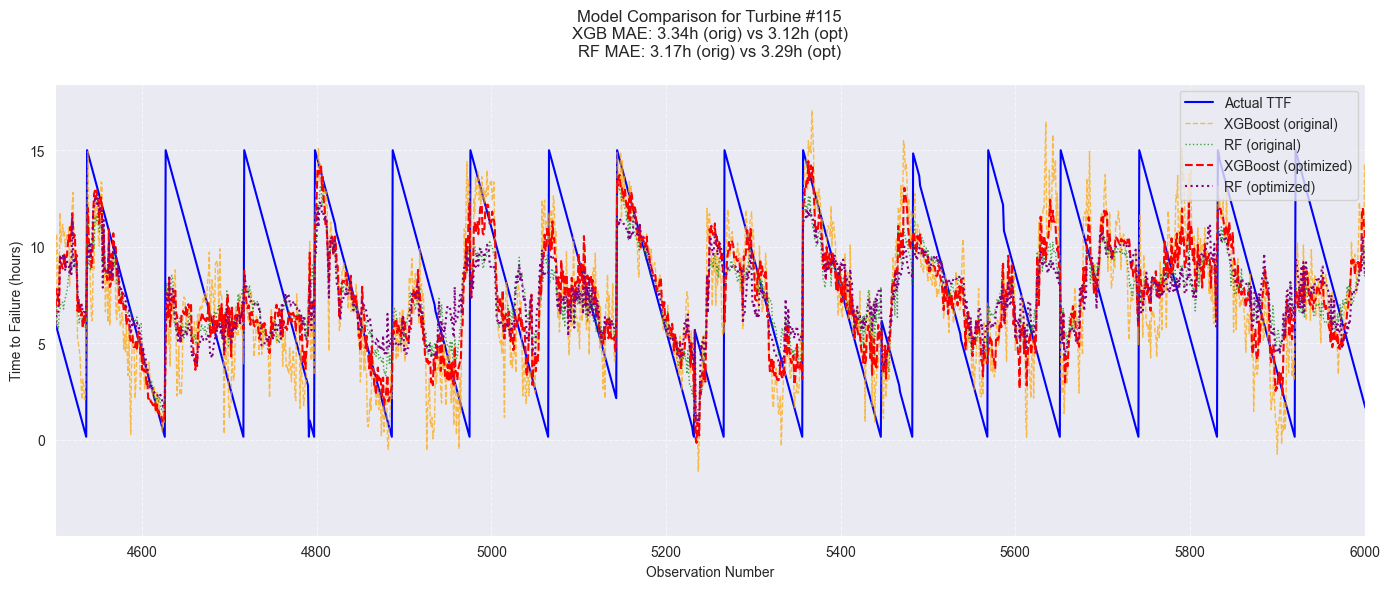

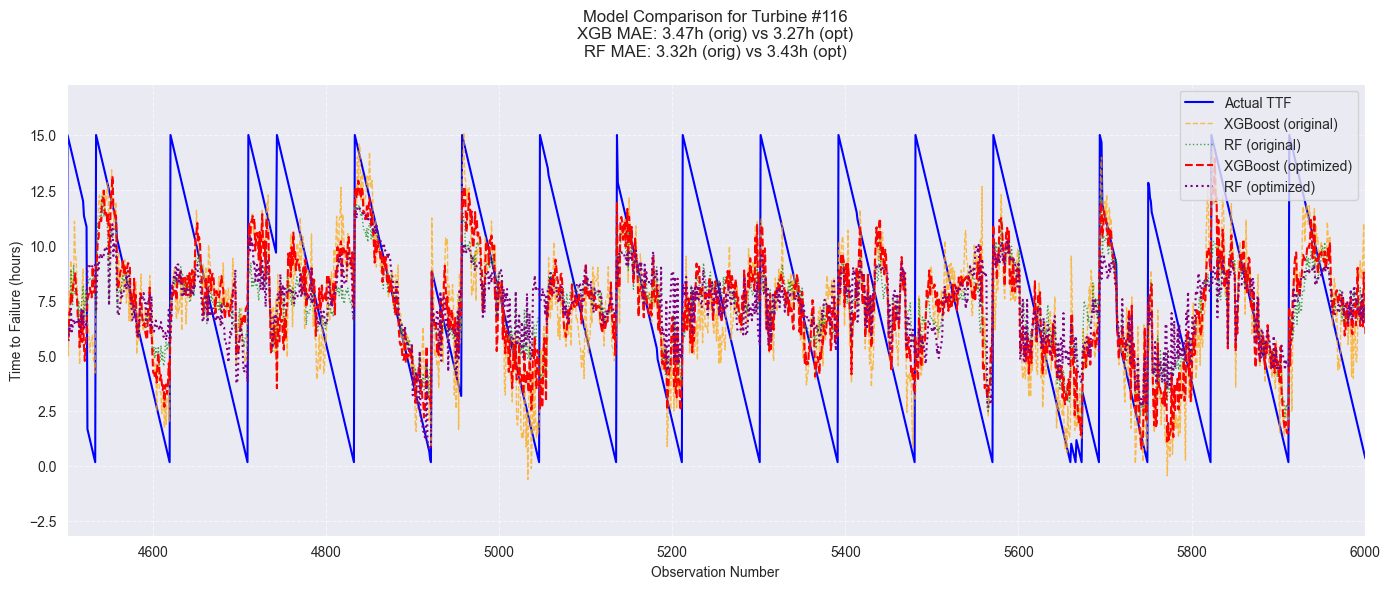

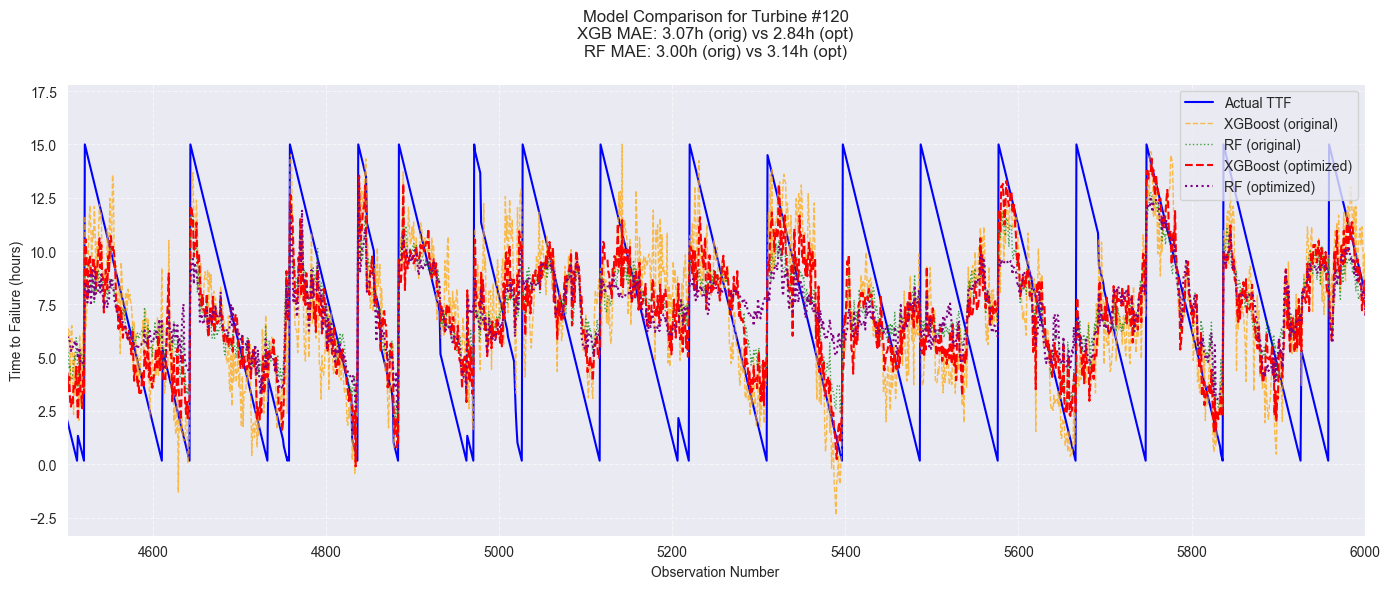

In [33]:
# First, install required package if not already installed
# !pip install scikit-optimize

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

# Define the search spaces for both models
xgb_search_space = {
    'n_estimators': Integer(100, 300),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, 'log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'gamma': Real(0, 5),
    'min_child_weight': Integer(1, 10)
}

rf_search_space = {
    'n_estimators': Integer(100, 300),
    'max_depth': Integer(3, 12),
    'max_features': Categorical(['sqrt', 'log2', None]),
    'min_samples_split': Integer(2, 8),
    'min_samples_leaf': Integer(1, 5),
    'bootstrap': Categorical([True, False])
}

# Initialize dictionary to store optimized models and results
optimized_models = {
    'xgb': {},
    'rf': {}
}

# Bayesian Optimization settings
n_iter = 30  # Number of iterations for optimization
cv = 3       # Number of cross-validation folds

# Perform optimization for each turbine in the Leave-One-Turbine-Out CV
for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    turbine_id = groups.iloc[test_index[0]]

    print(f"\nOptimizing models for turbine {turbine_id}...")

    # --- Optimize XGBoost ---
    print("Running Bayesian Optimization for XGBoost...")
    xgb_opt = BayesSearchCV(
        estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
        search_spaces=xgb_search_space,
        n_iter=n_iter,
        cv=cv,
        scoring='neg_mean_absolute_error',
        verbose=1,
        random_state=42
    )

    xgb_opt.fit(X_train, y_train)
    best_xgb = xgb_opt.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

    # --- Optimize Random Forest ---
    print("Running Bayesian Optimization for Random Forest...")
    rf_opt = BayesSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        search_spaces=rf_search_space,
        n_iter=n_iter,
        cv=cv,
        scoring='neg_mean_absolute_error',
        verbose=1,
        random_state=42
    )

    rf_opt.fit(X_train, y_train)
    best_rf = rf_opt.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)

    # Store optimized models and results
    optimized_models['xgb'][turbine_id] = {
        'model': best_xgb,
        'mae': xgb_mae,
        'params': xgb_opt.best_params_
    }

    optimized_models['rf'][turbine_id] = {
        'model': best_rf,
        'mae': rf_mae,
        'params': rf_opt.best_params_
    }

    # Update predictions dictionary
    if 'xgb_optimized_predicted' not in predictions[turbine_id]:
        predictions[turbine_id]['xgb_optimized_predicted'] = y_pred_xgb
    if 'rf_optimized_predicted' not in predictions[turbine_id]:
        predictions[turbine_id]['rf_optimized_predicted'] = y_pred_rf

    print(f"Turbine {turbine_id} optimization complete:")
    print(f"XGBoost best MAE: {xgb_mae:.2f}, params: {xgb_opt.best_params_}")
    print(f"Random Forest best MAE: {rf_mae:.2f}, params: {rf_opt.best_params_}")

# Compare results before and after optimization
print("\nModel Comparison - MAE Results by Turbine (hours):")
print("Turbine ID | XGBoost (orig) | XGBoost (opt) | RF (orig) | RF (opt) | Records")
print("---------------------------------------------------------------------------")
for turbine_id in sorted(predictions.keys()):
    rec_count = len(predictions[turbine_id]['actual'])
    print(f"{turbine_id:9} | {xgb_mae_results[turbine_id]:10.2f} | {optimized_models['xgb'][turbine_id]['mae']:12.2f} | {rf_mae_results[turbine_id]:8.2f} | {optimized_models['rf'][turbine_id]['mae']:8.2f} | {rec_count:7}")

# Update the plotting function to show optimized predictions
def plot_ttf_comparison(turbine_id, predictions, optimized_models):
    if turbine_id not in predictions:
        print(f"No data for turbine {turbine_id}")
        return

    data = predictions[turbine_id]
    obs_numbers = np.arange(len(data['timestamps']))

    plt.figure(figsize=(14, 6))
    plt.plot(obs_numbers, data['actual'], label='Actual TTF', color='blue', linewidth=1.5)

    # Original predictions
    plt.plot(obs_numbers, data['xgb_predicted'], label='XGBoost (original)', color='orange', linestyle='--', linewidth=1, alpha=0.7)
    plt.plot(obs_numbers, data['rf_predicted'], label='RF (original)', color='green', linestyle=':', linewidth=1, alpha=0.7)

    # Optimized predictions
    plt.plot(obs_numbers, data['xgb_optimized_predicted'], label='XGBoost (optimized)', color='red', linestyle='--', linewidth=1.5)
    plt.plot(obs_numbers, data['rf_optimized_predicted'], label='RF (optimized)', color='purple', linestyle=':', linewidth=1.5)

    plt.title(f"Model Comparison for Turbine #{turbine_id}\n"
              f"XGB MAE: {xgb_mae_results[turbine_id]:.2f}h (orig) vs {optimized_models['xgb'][turbine_id]['mae']:.2f}h (opt)\n"
              f"RF MAE: {rf_mae_results[turbine_id]:.2f}h (orig) vs {optimized_models['rf'][turbine_id]['mae']:.2f}h (opt)",
              pad=20)
    plt.xlabel("Observation Number")
    plt.ylabel("Time to Failure (hours)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    if len(obs_numbers) > 5700:
        plt.xlim(4500, 6000)

    plt.tight_layout()
    plt.show()

# Plot results for all turbines
for turbine_id in predictions.keys():
    plot_ttf_comparison(turbine_id, predictions, optimized_models)

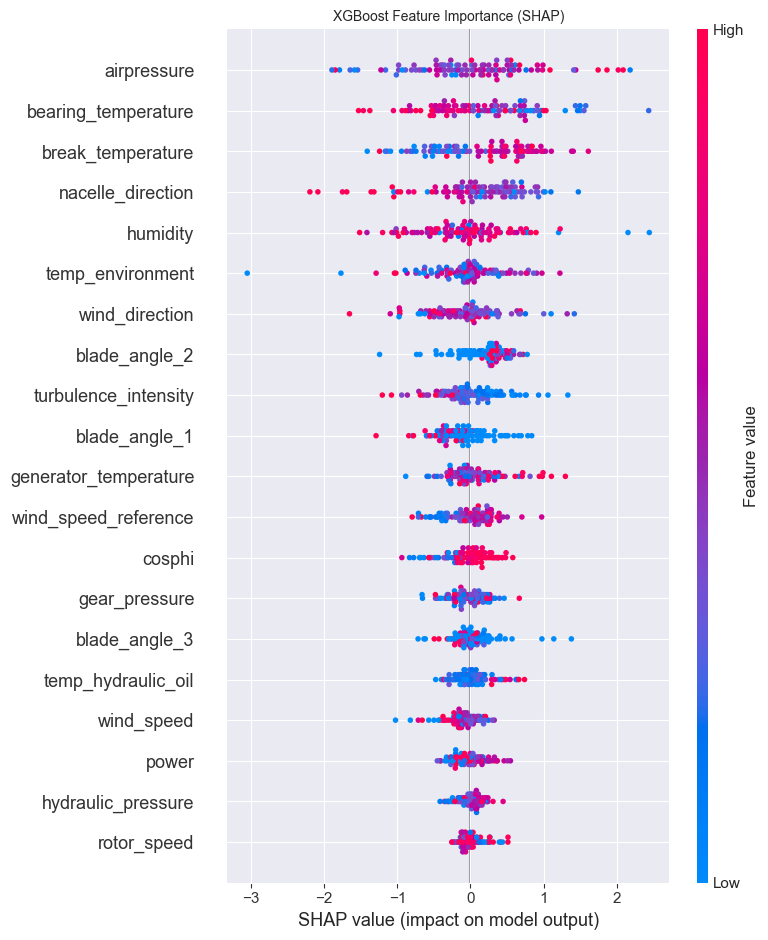

  0%|          | 0/100 [00:00<?, ?it/s]

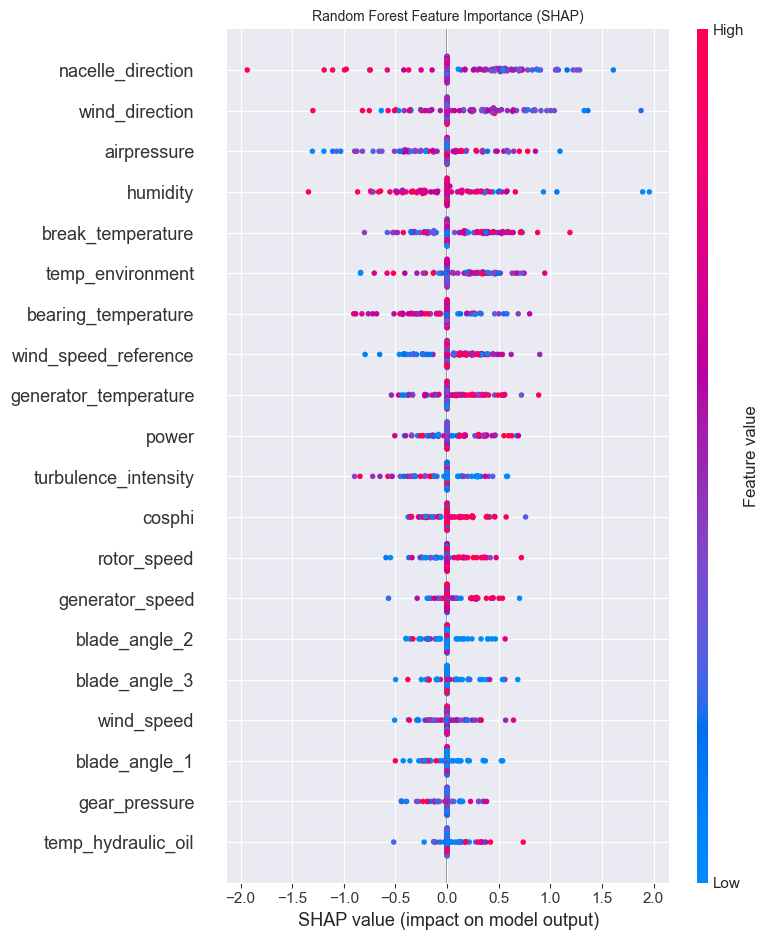

In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Subsample data (e.g., 100 samples for efficiency)
sample_idx = np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)
X_train_sampled = X_train.iloc[sample_idx, :]

# --- Plot 1: XGBoost SHAP (TreeExplainer) ---
plt.figure(figsize=(8, 5))
xgb_explainer = shap.TreeExplainer(xgb_model)  # Optimized for tree models
xgb_shap_values = xgb_explainer.shap_values(X_train_sampled)
shap.summary_plot(xgb_shap_values, X_train_sampled, feature_names=selected_features, show=False)
plt.title("XGBoost Feature Importance (SHAP)", fontsize=10)
plt.tight_layout()
plt.show()

# --- Plot 2: Random Forest SHAP (KernelSHAP approximation) ---
plt.figure(figsize=(8, 5))
rf_explainer = shap.KernelExplainer(rf_model.predict, X_train_sampled[:10])  # Small background
rf_shap_values = rf_explainer.shap_values(X_train_sampled, nsamples=200)  # Fewer samples
shap.summary_plot(rf_shap_values, X_train_sampled, feature_names=selected_features, show=False)
plt.title("Random Forest Feature Importance (SHAP)", fontsize=10)
plt.tight_layout()
plt.show()

In [36]:
import json
import pickle
import os
from datetime import datetime
import numpy as np

# Define save paths
SAVE_DIR = "optimization_results"
os.makedirs(SAVE_DIR, exist_ok=True)

def save_results(optimized_models, predictions, resume_data=None):
    """Save all results with timestamp"""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_data = {
        'optimized_models': optimized_models,
        'predictions': predictions,
        'timestamp': timestamp
    }

    if resume_data:
        save_data['resume_info'] = resume_data

    # Save as pickle (for Python objects)
    with open(f"{SAVE_DIR}/results_{timestamp}.pkl", 'wb') as f:
        pickle.dump(save_data, f)

    # Save as JSON (for human-readable parameters)
    json_data = {
        'optimized_models': {
            model_type: {
                turbine: {
                    'mae': data['mae'],
                    'params': data['params']
                }
                for turbine, data in turbines.items()
            }
            for model_type, turbines in optimized_models.items()
        },
        'timestamp': timestamp
    }

    with open(f"{SAVE_DIR}/results_{timestamp}.json", 'w') as f:
        json.dump(json_data, f, indent=2)

    print(f"Results saved to {SAVE_DIR}/results_{timestamp}.[pkl|json]")

def load_latest_results():
    """Load the most recent results"""
    try:
        files = [f for f in os.listdir(SAVE_DIR) if f.startswith('results_') and f.endswith('.pkl')]
        if not files:
            return None

        latest_file = sorted(files)[-1]
        with open(f"{SAVE_DIR}/{latest_file}", 'rb') as f:
            data = pickle.load(f)

        print(f"Loaded previous results from {latest_file}")
        return data

    except Exception as e:
        print(f"Error loading previous results: {e}")
        return None

# Initialize or load previous results
previous_results = load_latest_results()

if previous_results:
    print("\nPrevious optimization found with these completed turbines:")
    for model_type in ['xgb', 'rf']:
        print(f"{model_type.upper()}: {list(previous_results['optimized_models'][model_type].keys())}")

    resume = input("Do you want to resume from previous optimization? (y/n): ").lower() == 'y'
else:
    resume = False

if resume:
    optimized_models = previous_results['optimized_models']
    predictions = previous_results['predictions']
    completed_turbines = set(optimized_models['xgb'].keys())
    print(f"\nResuming from previous optimization. Already completed: {completed_turbines}")
else:
    optimized_models = {'xgb': {}, 'rf': {}}
    predictions = {}  # Initialize fresh if not resuming

# Get list of all unique turbine IDs
all_turbines = set(groups.unique())

# Determine which turbines need processing
if resume:
    remaining_turbines = list(all_turbines - completed_turbines)
    print(f"Turbines remaining to optimize: {remaining_turbines}")
else:
    remaining_turbines = list(all_turbines)

# Main optimization loop
for turbine_id in remaining_turbines:
    print(f"\nProcessing turbine {turbine_id}...")

    # Get indices for current turbine
    test_index = np.where(groups == turbine_id)[0]
    train_index = np.where(groups != turbine_id)[0]

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # --- XGBoost Optimization ---
    print("Optimizing XGBoost...")
    xgb_opt = BayesSearchCV(
        estimator=xgb.XGBRegressor(random_state=42, n_jobs=-1),
        search_spaces=xgb_search_space,
        n_iter=n_iter,
        cv=cv,
        scoring='neg_mean_absolute_error',
        verbose=1,
        random_state=42
    )

    xgb_opt.fit(X_train, y_train)
    best_xgb = xgb_opt.best_estimator_
    y_pred_xgb = best_xgb.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, y_pred_xgb)

    # --- Random Forest Optimization ---
    print("Optimizing Random Forest...")
    rf_opt = BayesSearchCV(
        estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
        search_spaces=rf_search_space,
        n_iter=n_iter,
        cv=cv,
        scoring='neg_mean_absolute_error',
        verbose=1,
        random_state=42
    )

    rf_opt.fit(X_train, y_train)
    best_rf = rf_opt.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)

    # Store results
    optimized_models['xgb'][turbine_id] = {
        'model': best_xgb,
        'mae': xgb_mae,
        'params': xgb_opt.best_params_,
        'optimizer': xgb_opt
    }

    optimized_models['rf'][turbine_id] = {
        'model': best_rf,
        'mae': rf_mae,
        'params': rf_opt.best_params_,
        'optimizer': rf_opt
    }

    # Update predictions
    if turbine_id not in predictions:
        predictions[turbine_id] = {}

    predictions[turbine_id].update({
        'actual': y_test.values,
        'xgb_predicted': y_pred_xgb,
        'rf_predicted': y_pred_rf,
        'xgb_optimized_predicted': y_pred_xgb,
        'rf_optimized_predicted': y_pred_rf,
        'timestamps': data_ttf.iloc[test_index]['timestamp'].values,
        'features': X_test.values
    })

    # Save after each turbine (checkpoint)
    save_results(optimized_models, predictions, {
        'completed_turbines': list(optimized_models['xgb'].keys()),
        'remaining_turbines': list(all_turbines - set(optimized_models['xgb'].keys()))
    })

# Final save
save_results(optimized_models, predictions)

# Analysis and visualization code remains the same as before
# [Previous plotting and analysis code here]


Processing turbine 109...
Optimizing XGBoost...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


KeyboardInterrupt: 